Import Libraries

In [1]:
import pandas as pd
import numpy as np
import ast

Load BOTH datasets

In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

Merge datasets

In [3]:
movies = movies.merge(credits, on='title')

Select useful columns

In [4]:
movies = movies[
    [
        'title',
        'genres',
        'cast',
        'crew',
        'release_date',
        'vote_average',
        'budget',
        'original_language',
        'popularity'
    ]
]

Remove null values

In [5]:
movies.dropna(inplace=True)

Extract year

In [6]:
movies['year'] = movies['release_date'].apply(
    lambda x: int(x.split("-")[0])
)

Convert genres

In [7]:
def convert(obj):

    L = []

    for i in ast.literal_eval(obj):
        L.append(i['name'])

    return L

movies['genres'] = movies['genres'].apply(convert)

Extract cast

In [8]:
def get_cast(obj):

    L = []
    counter = 0

    for i in ast.literal_eval(obj):

        if counter != 3:
            L.append(i['name'])
            counter += 1

        else:
            break

    return L

movies['cast'] = movies['cast'].apply(get_cast)

Extract director

In [9]:
def fetch_director(obj):

    L = []

    for i in ast.literal_eval(obj):

        if i['job'] == 'Director':
            L.append(i['name'])
            break

    return L

movies['crew'] = movies['crew'].apply(fetch_director)

Clean spaces

In [10]:
movies['genres'] = movies['genres'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

movies['cast'] = movies['cast'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

movies['crew'] = movies['crew'].apply(
    lambda x:[i.replace(" ","") for i in x]
)

Create tags

In [11]:
movies['tags'] = (
    movies['genres'] +
    movies['cast'] +
    movies['crew']
)

Convert tags to text

In [12]:
movies['tags'] = movies['tags'].apply(
    lambda x:" ".join(x)
)

Vectorization

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)

vectors = cv.fit_transform(
    movies['tags']
).toarray()

Add year feature

In [14]:
year_feature = movies['year'].values.reshape(-1,1)

X = np.concatenate(
    (vectors, year_feature),
    axis=1
)

y = movies['vote_average']

Train-test split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Import models

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error

Model comparison

In [17]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(),

    "Random Forest": RandomForestRegressor(),

    "Gradient Boosting": GradientBoostingRegressor()
}

Train & compare ALL models

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

# MSE
mse_lr = mean_squared_error(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)

Linear Regression MSE: 8.309605081319155


In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Model
dt = DecisionTreeRegressor()

# Train
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(X_test)

# MSE
mse_dt = mean_squared_error(y_test, y_pred_dt)

print("Decision Tree MSE:", mse_dt)

Decision Tree MSE: 1.512411064911065


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Model
rf = RandomForestRegressor()

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# MSE
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)

Random Forest MSE: 1.0830415729499303


In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# Model
gb = GradientBoostingRegressor()

# Train
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# MSE
mse_gb = mean_squared_error(y_test, y_pred_gb)

print("Gradient Boosting MSE:", mse_gb)

Gradient Boosting MSE: 1.0925177349741346


RandomForestRegressor()

In [22]:
from sklearn.ensemble import RandomForestRegressor

# FINAL MODEL
model = RandomForestRegressor()

# TRAIN
model.fit(X_train, y_train)

# PREDICT
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("MAE :", mae)
print("R2 Score :", r2)

MSE : 1.0927421204325312
MAE : 0.6989045247170248
R2 Score : 0.1352741437395758


In [24]:
import joblib

# =========================
# SAVE MODEL
# =========================
joblib.dump(model, "movie_model.pkl")

# =========================
# SAVE VECTORIZER
# =========================
joblib.dump(cv, "vectorizer.pkl")

print("✅ Model and Vectorizer Saved Successfully")

✅ Model and Vectorizer Saved Successfully


In [25]:
import os

print(os.listdir())

['.git', '.ipynb_checkpoints', 'app.py', 'cleaned_ott_movies_dataset.csv', 'final_ott_trend_analysis.csv', 'movies.ipynb', 'movie_model.pkl', 'requirements.txt', 'tmdb_5000_credits.csv', 'tmdb_5000_movies.csv', 'vectorizer.pkl']


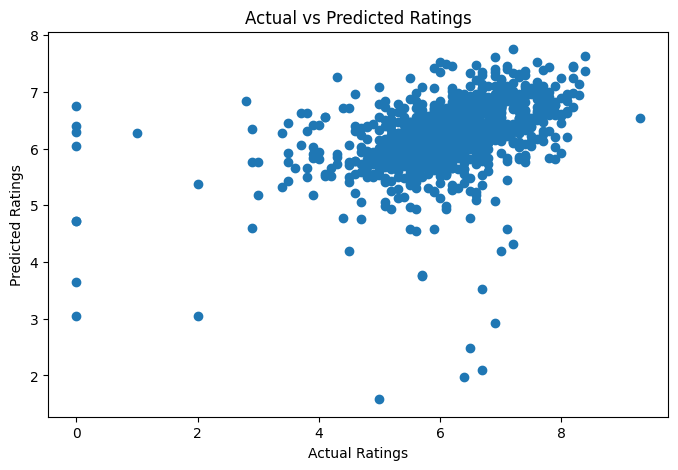

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

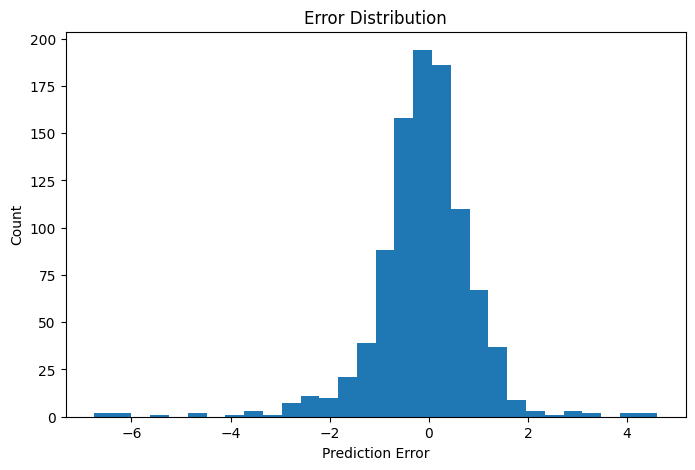

In [27]:
errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.xlabel("Prediction Error")
plt.ylabel("Count")

plt.title("Error Distribution")

plt.show()

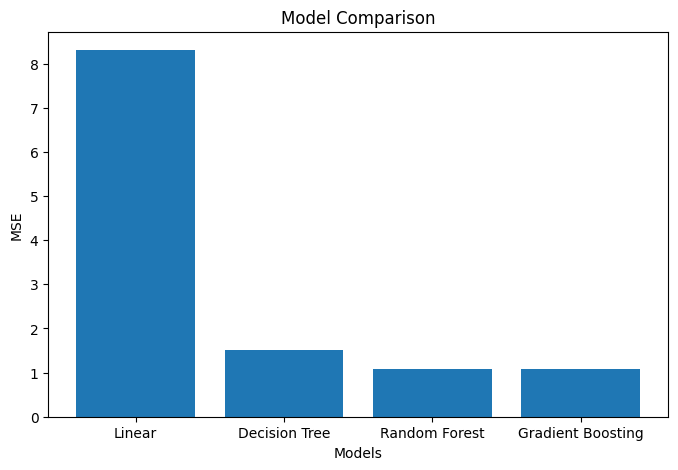

In [28]:
models_names = [
    "Linear",
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting"
]

mse_values = [
    mse_lr,
    mse_dt,
    mse_rf,
    mse_gb
]

plt.figure(figsize=(8,5))

plt.bar(models_names, mse_values)

plt.xlabel("Models")
plt.ylabel("MSE")

plt.title("Model Comparison")

plt.show()

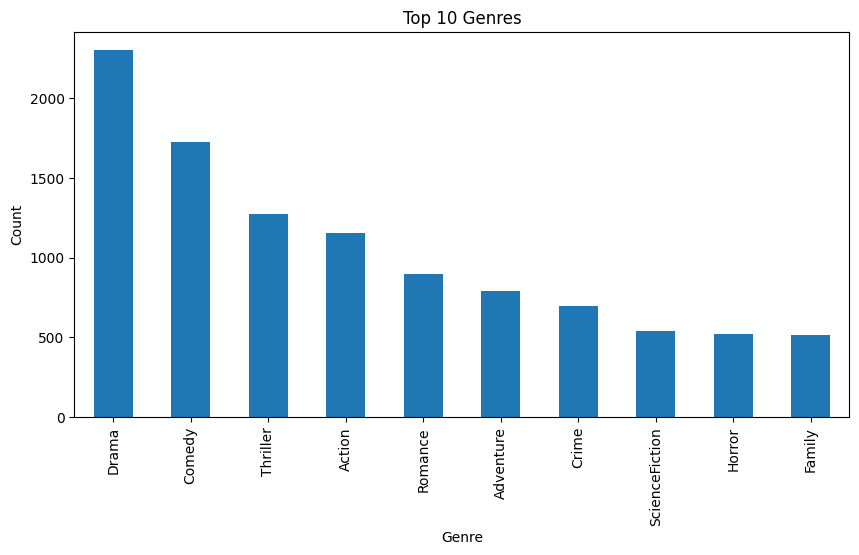

In [29]:
genre_counts = movies['genres'].explode().value_counts().head(10)

plt.figure(figsize=(10,5))

genre_counts.plot(kind='bar')

plt.title("Top 10 Genres")

plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

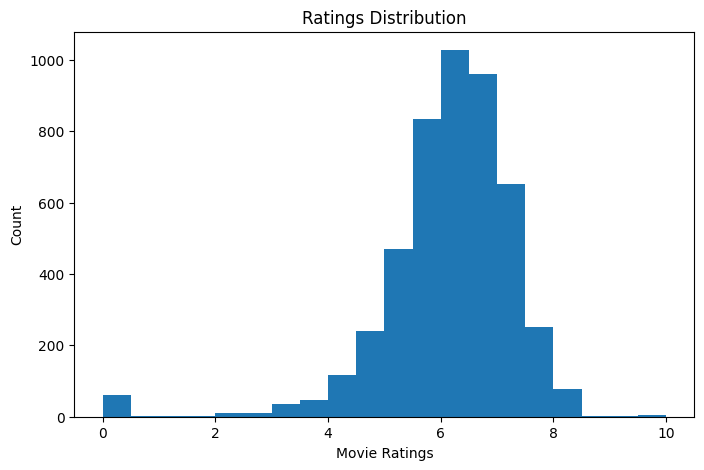

In [30]:
plt.figure(figsize=(8,5))

plt.hist(movies['vote_average'], bins=20)

plt.xlabel("Movie Ratings")
plt.ylabel("Count")

plt.title("Ratings Distribution")

plt.show()

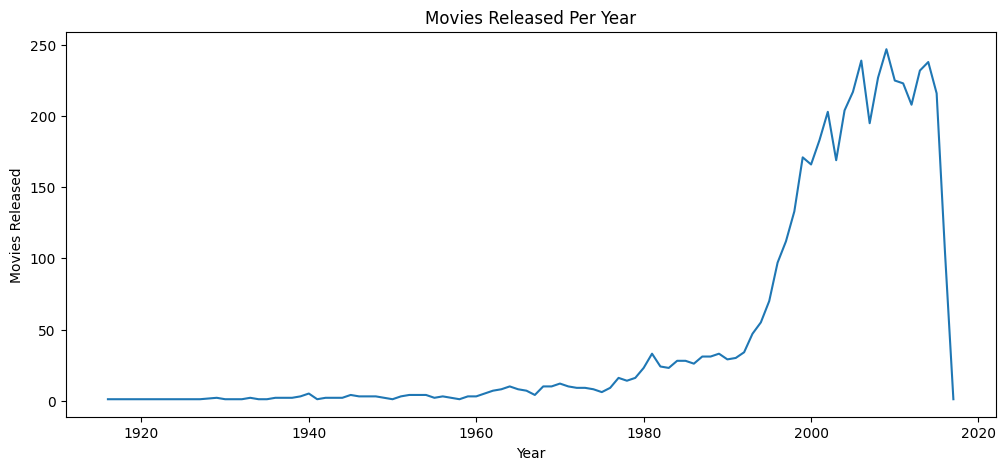

In [31]:
movies_per_year = movies['year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(
    movies_per_year.index,
    movies_per_year.values
)

plt.xlabel("Year")
plt.ylabel("Movies Released")

plt.title("Movies Released Per Year")

plt.show()

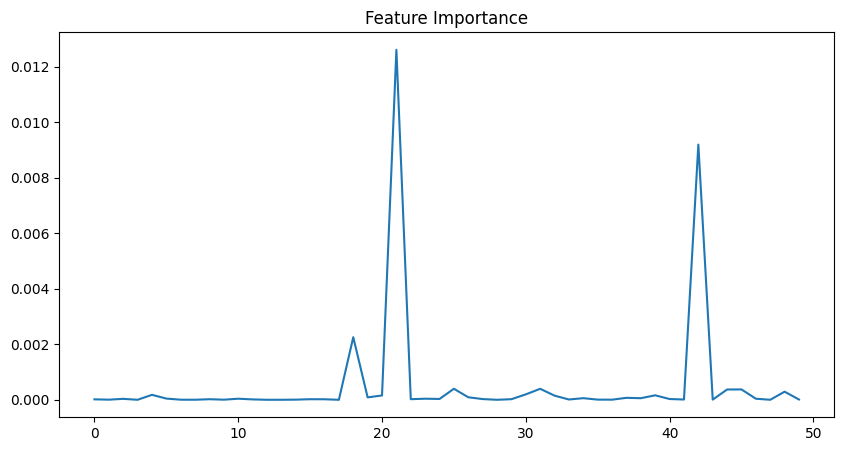

In [32]:
importance = model.feature_importances_

plt.figure(figsize=(10,5))

plt.plot(importance[:50])

plt.title("Feature Importance")

plt.show()